In [8]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [2]:
data = load_iris()

In [10]:
X = data.data

In [4]:
y = data.target

In [24]:
print("Flower categories:")
for number, flower_name in enumerate(data.target_names):
    print(number, "=", flower_name)

Flower categories:
0 = setosa
1 = versicolor
2 = virginica


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

In [13]:
model_1 = make_pipeline(StandardScaler(), MLPClassifier(hidden_layer_sizes = (10,), max_iter = 1000, random_state = 42))

In [14]:
model_2 = make_pipeline(StandardScaler(), MLPClassifier(hidden_layer_sizes = (20, 10), max_iter = 1000, random_state = 42))

In [ ]:
cv_score_1 = cross_val_score(model_1, X, y, cv = 5, scoring = "accuracy")
cv_score_2 = cross_val_score(model_2, X, y, cv = 5, scoring = "accuracy")

c:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [16]:
print("Architecture 1 - Hidden layers: (10,)")
print("Cross-validation accuracy:", cv_score_1)
print("Mean CV accuracy:", cv_score_1.mean())

Architecture 1 - Hidden layers: (10,)
Cross-validation accuracy: [1.         0.96666667 0.93333333 0.93333333 0.96666667]
Mean CV accuracy: 0.9600000000000002


In [ ]:
print("Architecture 2 - Hidden layers: (20, 10)")
print("Cross-validation accuracy:", cv_score_2)
print("Mean CV accuracy:", cv_score_2.mean())


Architecture 2 - Hidden layers: (20, 10)
Cross-validation accuracy: [0.96666667 0.96666667 0.93333333 0.93333333 1.        ]
Mean CV accuracy: 0.96


In [18]:
model_1.fit(X_train, y_train)
y_pred_1 = model_1.predict(X_test)

In [ ]:
print("Architecture 1 Test Accuracy:", accuracy_score(y_test, y_pred_1))
print("Architecture 1 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_1))


Architecture 1 Test Accuracy: 0.9666666666666667
Architecture 1 Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


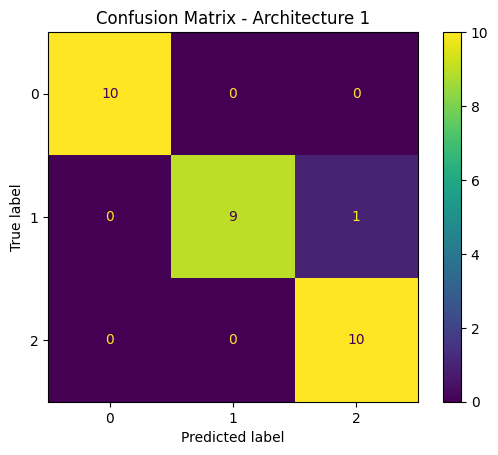

In [20]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_1)
plt.title("Confusion Matrix - Architecture 1")
plt.show()

In [21]:
model_2.fit(X_train, y_train)
y_pred_2 = model_2.predict(X_test)

In [ ]:
print("Architecture 2 Test Accuracy:", accuracy_score(y_test, y_pred_2))
print("Architecture 2 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_2))


Architecture 2 Test Accuracy: 0.9666666666666667
Architecture 2 Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


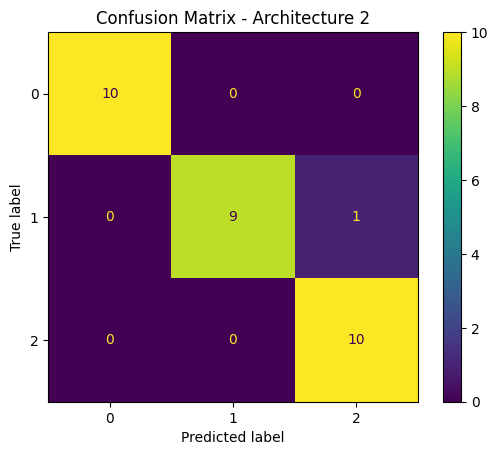

In [23]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_2)
plt.title("Confusion Matrix - Architecture 2")
plt.show()

Both models produced the same confusion matrix.

All 10 Setosa samples were classified correctly.

For Versicolor, 9 of 10 were correct and 1 was incorrectly classified as Virginica.

All 10 Virginica samples were classified correctly.

Both architectures perform equally well on this dataset, so the simpler (10,) architecture is preferable because it uses fewer neurons.